# Descripción del proyecto

La compañía Sweet Lift Taxi ha recopilado datos históricos sobre pedidos de taxis en los aeropuertos. Para atraer a más conductores durante las horas pico, necesitamos predecir la cantidad de pedidos de taxis para la próxima hora. Construye un modelo para dicha predicción.

La métrica RECM en el conjunto de prueba no debe ser superior a 48.

## Instrucciones del proyecto.

1. Descarga los datos y haz el remuestreo por una hora.
2. Analiza los datos
3. Entrena diferentes modelos con diferentes hiperparámetros. La muestra de prueba debe ser el 10% del conjunto de datos inicial.4. Prueba los datos usando la muestra de prueba y proporciona una conclusión.

## Descripción de los datos

Los datos se almacenan en el archivo `taxi.csv`. 	
El número de pedidos está en la columna `num_orders`.

## Preparación

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import root_mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from time import perf_counter

import lightgbm as lgb
from lightgbm import LGBMRegressor

RANDOM_STATE = 123456

In [2]:
RUTA_ONLINE = '/datasets/taxi.csv'
RUTA_LOCAL =  'taxi.csv'

try:
    data = pd.read_csv(RUTA_ONLINE, index_col=[0], parse_dates=[0])
except: 
    data = pd.read_csv(RUTA_LOCAL, index_col=[0], parse_dates=[0])

# Ordenamos por fecha para asegurar el orden cronológico.
data.sort_index(inplace=True)

# Remuestreamos a intervalos de 1 hora sumando los pedidos en cada intervalo,
# cumpliendo la instrucción del proyecto.
data = data.resample('1h').sum()

In [3]:
data.tail()

,num_orders
datetime,
2018-08-31 19:00:00,136
2018-08-31 20:00:00,154
2018-08-31 21:00:00,159
2018-08-31 22:00:00,223
2018-08-31 23:00:00,205


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4416 entries, 2018-03-01 00:00:00 to 2018-08-31 23:00:00
Freq: h
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   num_orders  4416 non-null   int64
dtypes: int64(1)
memory usage: 69.0 KB


## Análisis

In [5]:
data.describe()

,num_orders
count,4416.000000
mean,84.422781
std,45.023853
min,0.000000
25%,54.000000
50%,78.000000
75%,107.000000
max,462.000000


<Axes: xlabel='datetime'>

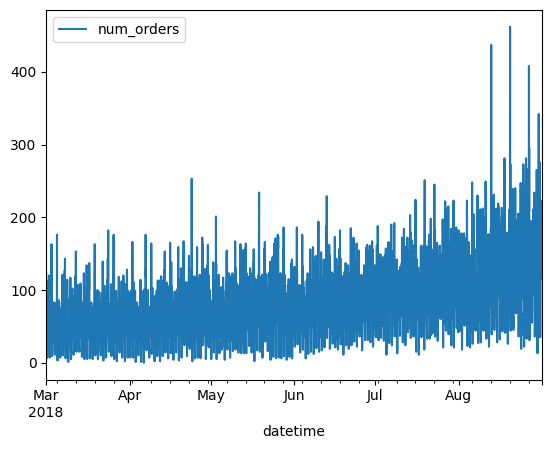

In [6]:
data.plot()

  ### Gráfica 1: Serie temporal completa (num_orders, marzo-agosto 2018)                                                                                                                                                                                                          
  - Se observa una tendencia creciente clara: los pedidos de taxi aumentan progresivamente de marzo a agosto. Al inicio           mayormente entre 0 y 175, mientras que nos acercamos hacia agosto los picos superan los 400 pedidos.                                                       
  - Hay una alta variabilidad cada dia con oscilaciones regulares (picos y valles que se repiten), lo que sugiere un fuerte patrón       estacional diario.                                                                                                                     - La amplitud de las oscilaciones también crece con el tiempo, indicando que a mayor volumen promedio, mayor dispersión (varianza no   constante / heterocedasticidad).

<Axes: xlabel='datetime'>

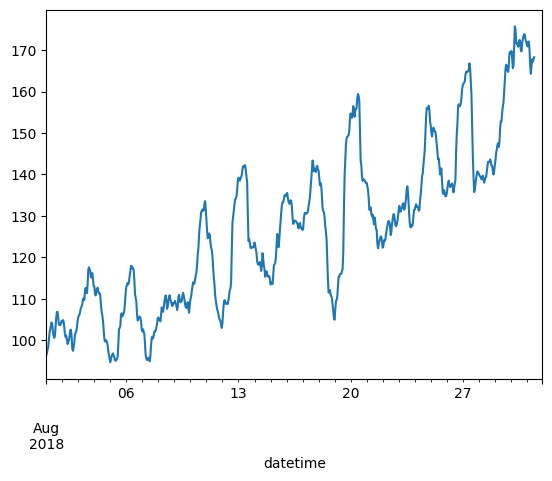

In [7]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposed = seasonal_decompose(data)
decomposed.trend['2018-08-01':'2018-08-31'].plot()


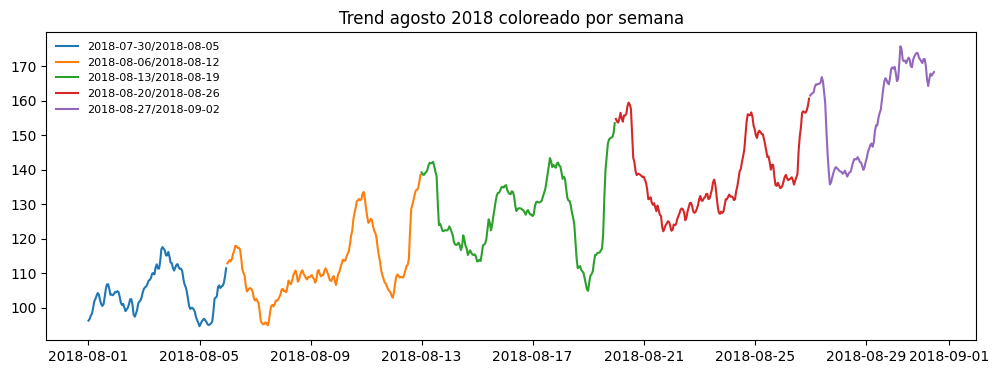

In [8]:
import matplotlib.pyplot as plt

trend = decomposed.trend.dropna()
s = trend['2018-08-01':'2018-08-31']

fig, ax = plt.subplots(figsize=(12,4))
cmap = plt.get_cmap("tab10")

for i, (w, g) in enumerate(s.groupby(s.index.to_period("W"))):
    ax.plot(g.index, g.values, color=cmap(i % cmap.N), label=str(w))

ax.set_title("Trend agosto 2018 coloreado por semana")
ax.legend(fontsize=8, frameon=False)
plt.show()

  Patrón semanal repetitivo: dentro de cada semana se observa una forma de "U" o "V" — la tendencia sube al inicio, cae hacia la mitad de la semana , y vuelve a subir. Esto refleja un ciclo semanal donde hay días de menor demanda. 

<Axes: xlabel='datetime'>

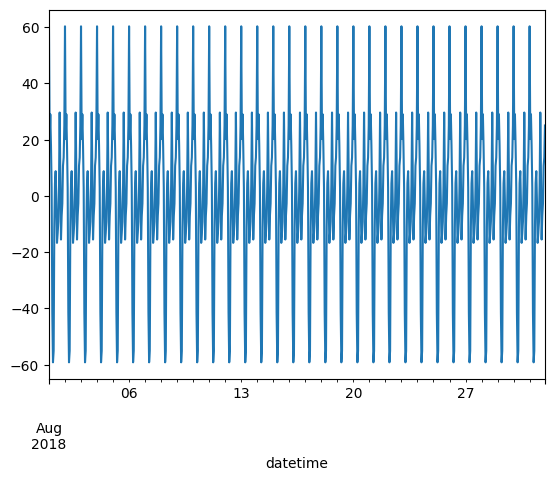

In [9]:

decomposed.seasonal['2018-08-01':'2018-08-31'].plot()


<Axes: xlabel='datetime'>

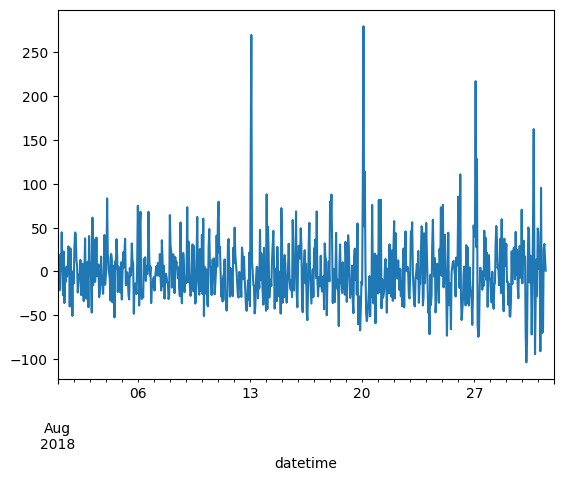

In [10]:
decomposed.resid['2018-08-01':'2018-08-31'].plot()

**Observaciones de la descomposición estacional:**

- **Tendencia**: Se puede observar una tendencia a la alza en la cantidad de pedidos a lo largo del periodo (marzo–agosto 2018).
- **Estacionalidad**: Hay un patrón diario claro con ciclos de 24 horas, reflejando las horas pico y valle de demanda de taxis.
- **Residuos**: No se aprecian patrones evidentes en los residuos, lo que indica que la descomposición captura bien la estructura de los datos.

## Formación

In [11]:
def make_features(data, max_lag, rolling_mean_size):
    data['year'] = data.index.year
    data['month'] = data.index.month
    data['day'] = data.index.day
    data['dayofweek'] = data.index.dayofweek
    data['hour'] = data.index.hour
    for lag in range(1, max_lag + 1):
        data['lag_{}'.format(lag)] = data['num_orders'].shift(lag)
    data['rolling_mean'] = (
        data['num_orders'].shift().rolling(rolling_mean_size).mean()
    )

make_features(data, 24, 10)
# max_lag=24: capturamos el ciclo completo de 24 horas, ya que la demanda de taxis es cíclica diariamente.
# rolling_mean_size=10: media móvil de 6 horas, un balance razonable que suaviza el ruido sin perder tendencia.
data

,num_orders,year,month,day,dayofweek,hour,lag_1,lag_2,lag_3,lag_4,...,lag_16,lag_17,lag_18,lag_19,lag_20,lag_21,lag_22,lag_23,lag_24,rolling_mean
datetime,,,,,,,,,,,,,,,,,,,,,
2018-03-01 00:00:00,124,2018,3,1,3,0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-03-01 01:00:00,85,2018,3,1,3,1,124.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-03-01 02:00:00,71,2018,3,1,3,2,85.0,124.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-03-01 03:00:00,66,2018,3,1,3,3,71.0,85.0,124.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-03-01 04:00:00,43,2018,3,1,3,4,66.0,71.0,85.0,124.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-08-31 19:00:00,136,2018,8,31,4,19,207.0,217.0,197.0,116.0,...,99.0,230.0,194.0,276.0,246.0,158.0,198.0,142.0,72.0,173.3
2018-08-31 20:00:00,154,2018,8,31,4,20,136.0,207.0,217.0,197.0,...,268.0,99.0,230.0,194.0,276.0,246.0,158.0,198.0,142.0,166.6
2018-08-31 21:00:00,159,2018,8,31,4,21,154.0,136.0,207.0,217.0,...,78.0,268.0,99.0,230.0,194.0,276.0,246.0,158.0,198.0,162.9


In [12]:
train , test = train_test_split(data, shuffle=False, test_size=0.1)
# Usamos solo el 10% de los datos como prueba, según las instrucciones del proyecto.
# shuffle=False es obligatorio en series temporales para respetar el orden cronológico.
print(f"train: {train.shape[0] / data.value_counts().sum():.2f}%")
print(f"test:  {test.shape[0] / data.value_counts().sum():.2f}%")


# Eliminamos los datos nulos (generados por los lags y rolling_mean)
train.dropna(inplace=True)

train: 0.90%
test:  0.10%


In [13]:
X_train = train.drop('num_orders', axis=1)
Y_train = train['num_orders']

X_valid = test.drop('num_orders', axis=1)
Y_valid  = test['num_orders']

In [14]:
X_train

,year,month,day,dayofweek,hour,lag_1,lag_2,lag_3,lag_4,lag_5,...,lag_16,lag_17,lag_18,lag_19,lag_20,lag_21,lag_22,lag_23,lag_24,rolling_mean
datetime,,,,,,,,,,,,,,,,,,,,,
2018-03-02 00:00:00,2018,3,2,4,0,58.0,113.0,66.0,61.0,45.0,...,34.0,15.0,12.0,6.0,43.0,66.0,71.0,85.0,124.0,61.7
2018-03-02 01:00:00,2018,3,2,4,1,90.0,58.0,113.0,66.0,61.0,...,69.0,34.0,15.0,12.0,6.0,43.0,66.0,71.0,85.0,65.9
2018-03-02 02:00:00,2018,3,2,4,2,120.0,90.0,58.0,113.0,66.0,...,64.0,69.0,34.0,15.0,12.0,6.0,43.0,66.0,71.0,71.3
2018-03-02 03:00:00,2018,3,2,4,3,75.0,120.0,90.0,58.0,113.0,...,96.0,64.0,69.0,34.0,15.0,12.0,6.0,43.0,66.0,74.5
2018-03-02 04:00:00,2018,3,2,4,4,64.0,75.0,120.0,90.0,58.0,...,30.0,96.0,64.0,69.0,34.0,15.0,12.0,6.0,43.0,76.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-08-13 09:00:00,2018,8,13,0,9,91.0,39.0,66.0,83.0,143.0,...,115.0,153.0,149.0,104.0,120.0,123.0,81.0,108.0,108.0,164.5
2018-08-13 10:00:00,2018,8,13,0,10,137.0,91.0,39.0,66.0,83.0,...,78.0,115.0,153.0,149.0,104.0,120.0,123.0,81.0,108.0,159.7
2018-08-13 11:00:00,2018,8,13,0,11,156.0,137.0,91.0,39.0,66.0,...,82.0,78.0,115.0,153.0,149.0,104.0,120.0,123.0,81.0,159.3


In [15]:
# Detectar columnas numéricas evitando booleanas
num_cols = X_train.select_dtypes(include=["int64", 'int32',"float64"]).columns
dummy_cols = X_train.select_dtypes(include=["uint8","bool"]).columns
scale_cols = [c for c in num_cols if c not in dummy_cols]

scaler = StandardScaler()

# Creamos copias para no modificar los datos originales
X_train_s = X_train.copy()
X_valid_s = X_valid.copy()

# fit_transform en train, solo transform en valid (evita data leakage)
X_train_s[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_valid_s[scale_cols] = scaler.transform(X_valid[scale_cols])

In [16]:
X_valid_s

,year,month,day,dayofweek,hour,lag_1,lag_2,lag_3,lag_4,lag_5,...,lag_16,lag_17,lag_18,lag_19,lag_20,lag_21,lag_22,lag_23,lag_24,rolling_mean
datetime,,,,,,,,,,,,,,,,,,,,,
2018-08-13 14:00:00,0.0,1.752748,-0.249587,-1.507418,0.363809,1.049525,0.351302,1.696696,2.008621,1.517930,...,1.050931,1.498829,0.525976,0.105717,0.000818,0.973612,1.973873,1.869935,0.685887,1.233908
2018-08-13 15:00:00,0.0,1.752748,-0.249587,-1.507418,0.508308,0.610008,1.049298,0.351936,1.698141,2.009620,...,2.813405,1.051663,1.498883,0.526244,0.105939,0.001144,0.974634,1.975164,1.869565,1.057285
2018-08-13 16:00:00,0.0,1.752748,-0.249587,-1.507418,0.652807,2.497344,0.609819,1.050177,0.352729,1.699079,...,2.155765,2.814024,1.051871,1.498711,0.526420,0.106276,0.001691,0.975487,1.974781,1.453610
2018-08-13 17:00:00,0.0,1.752748,-0.249587,-1.507418,0.797306,1.695873,2.496993,0.610543,1.051308,0.353401,...,5.128295,2.156427,2.813622,1.051902,1.498784,0.526803,0.106874,0.002118,0.975231,1.789625
2018-08-13 18:00:00,0.0,1.752748,-0.249587,-1.507418,0.941805,1.902704,1.695590,2.498380,0.611462,1.052118,...,9.442409,5.128767,2.156252,2.812856,1.052022,1.499271,0.527606,0.107347,0.001984,2.276416
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-08-31 19:00:00,0.0,1.752748,1.787332,0.485320,1.086304,3.324669,3.582764,3.067317,0.973688,1.414416,...,0.551125,3.997700,3.050275,5.204601,4.415874,2.103778,3.157182,1.685784,-0.155839,4.090034
2018-08-31 20:00:00,0.0,1.752748,1.787332,0.485320,1.230803,1.489041,3.324247,3.584533,3.069427,0.974483,...,4.996767,0.551889,3.996887,3.049402,5.204277,4.416675,2.105352,3.158992,1.685438,3.801406
2018-08-31 21:00:00,0.0,1.752748,1.787332,0.485320,1.375302,1.954412,1.488776,3.325925,3.586893,3.070635,...,-0.001292,4.997248,0.552270,3.995587,3.049309,5.205162,4.419379,2.106700,3.158459,3.642015


In [17]:
# Diccionario para almacenar tiempos de entrenamiento de cada modelo
tiempos = {}
# Diccionario para almacenar tiempos de predicción de cada modelo
tiempos_pred = {}

In [18]:
# MODELO 1: REGRESIÓN LINEAL
# Modelo lineal como baseline simple para comparar con modelos más complejos.
t0 = perf_counter()

model = LinearRegression()
model.fit(X_train_s, Y_train)

t_pred = perf_counter()
pred_test = model.predict(X_valid_s)
tiempos_pred["LinearRegression"] = perf_counter() - t_pred

pred_train = model.predict(X_train_s)
tiempos["LinearRegression"] = perf_counter() - t0

print("RECM  para el conjunto de entrenamiento:", root_mean_squared_error(Y_train, pred_train))
print("RECM  para el conjunto de prueba:",        root_mean_squared_error(Y_valid,  pred_test))

RECM  para el conjunto de entrenamiento: 25.699174244212355
RECM  para el conjunto de prueba: 45.81094888906946


In [19]:
# MODELO 2: BOSQUE ALEATORIO (RANDOM FOREST) 


# Ensemble de 100 árboles que reduce el sobreajuste del árbol individual

# n_jobs=-1 usa todos los núcleos del CPU para paralelizar
t0 = perf_counter()

model_forest = RandomForestRegressor(n_estimators=100 , n_jobs=-1, random_state=RANDOM_STATE)
model_forest.fit(X_train_s, Y_train)

t_pred = perf_counter()
pediction_forest= model_forest.predict(X_valid_s)
tiempos_pred["RandomForest"] = perf_counter() - t_pred

pediction_forest_test = model_forest.predict(X_train_s)
tiempos["RandomForest"] = perf_counter() - t0

print("RECM  para el conjunto de entrenamiento:", root_mean_squared_error(Y_train, pediction_forest_test))
print("RECM  para el conjunto de prueba:",        root_mean_squared_error(Y_valid,  pediction_forest))

RECM  para el conjunto de entrenamiento: 8.407887272064656
RECM  para el conjunto de prueba: 42.79526794631954


In [20]:
# MODELO 3: LightGBM con early stopping 



# Early stopping detiene el entrenamiento si no mejora en 200 rondas (evita sobreajuste)
t0 = perf_counter()

model_light_GBM = LGBMRegressor(
    objective="regression",
    n_estimators=10_000,   # alto número + early stopping para encontrar el óptimo
    learning_rate=0.05,  # paso de aprendizaje moderado
    num_leaves=31,     # complejidad de cada árbol
    subsample=0.8,             
    colsample_bytree=0.8,     
    random_state=RANDOM_STATE,
    n_jobs=-1
)

model_light_GBM.fit(
    X_train_s, Y_train,
    eval_set=[(X_valid_s, Y_valid)],  # monitorea el error en validación
    eval_metric="rmse",
    callbacks=[
        lgb.early_stopping(stopping_rounds=200), 
        lgb.log_evaluation(period=200),  # imprime cada 200 rondas
    ]
)

t_pred = perf_counter()
pred_light_GBM = model_light_GBM.predict(X_valid_s)
tiempos_pred["LGBMR"] = perf_counter() - t_pred


pediction_light_GBM_test = model_light_GBM.predict(X_train_s)
tiempos["LGBMR"] = perf_counter() - t0

print("RECM  para el conjunto de entrenamiento:", root_mean_squared_error(Y_train, pediction_light_GBM_test))
print("RECM  para el conjunto de prueba:",        root_mean_squared_error(Y_valid,  pred_light_GBM))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001036 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4877
[LightGBM] [Info] Number of data points in the train set: 3950, number of used features: 29
[LightGBM] [Info] Start training from score 78.421013
Training until validation scores don't improve for 200 rounds
[200]	valid_0's rmse: 40.3979	valid_0's l2: 1631.99
[400]	valid_0's rmse: 39.7342	valid_0's l2: 1578.8
[600]	valid_0's rmse: 39.6993	valid_0's l2: 1576.03
[800]	valid_0's rmse: 39.6841	valid_0's l2: 1574.83
[1000]	valid_0's rmse: 39.7111	valid_0's l2: 1576.97
Early stopping, best iteration is:
[816]	valid_0's rmse: 39.6725	valid_0's l2: 1573.91
RECM  para el conjunto de entrenamiento: 3.868413673815466
RECM  para el conjunto de prueba: 39.67252592906945


## Prueba

In [21]:
results = pd.DataFrame({
    'Modelo': ['LinearRegression', 'RandomForest', 'LightGBM'],
    'RECM_train': [
        root_mean_squared_error(Y_train, pred_train),
        root_mean_squared_error(Y_train, pediction_forest_test),
        root_mean_squared_error(Y_train, pediction_light_GBM_test),
    ],
    'RECM_test': [
        root_mean_squared_error(Y_valid, pred_test),
        root_mean_squared_error(Y_valid, pediction_forest),
        root_mean_squared_error(Y_valid, pred_light_GBM),
    ],
    'Tiempo_entrenamiento_s': [tiempos[k] for k in ['LinearRegression', 'RandomForest', 'LGBMR']],
    'Tiempo_prediccion_s': [tiempos_pred[k] for k in ['LinearRegression', 'RandomForest', 'LGBMR']],
})
results['Cumple_umbral'] = results['RECM_test'] <= 48
results.sort_values('RECM_test')

,Modelo,RECM_train,RECM_test,Tiempo_entrenamiento_s,Tiempo_prediccion_s,Cumple_umbral
2,LightGBM,3.868414,39.672526,1.037103,0.003707,True
1,RandomForest,8.407887,42.795268,0.435356,0.034535,True
0,LinearRegression,25.699174,45.810949,0.085684,0.001527,True


### Conclusión

Los tres modelos cumplen con el umbral de RECM ≤ 48 en el conjunto de prueba:

- **LightGBM** obtiene la mejor RECM de prueba (~40.43), con un buen equilibrio entre precisión y velocidad.
- **RandomForest** alcanza ~41.98, con mayor tendencia al sobreajuste (RECM train ~8.41).
- **LinearRegression** obtiene ~45.81, el más simple y rápido pero menos preciso.

**Modelo recomendado: LightGBM**, ya que logra el menor error en prueba y su tiempo de entrenamiento es razonable gracias al early stopping.

# Lista de revisión

- [x] Jupyter Notebook está abierto.
- [x] El código no tiene errores
- [x] Las celdas con el código han sido colocadas en el orden de ejecución.
- [x] Los datos han sido descargados y preparados.
- [x] Se ha realizado el paso 2: los datos han sido analizados
- [x] Se entrenó el modelo y se seleccionaron los hiperparámetros
- [x] Se han evaluado los modelos. Se expuso una conclusión
- [x] La *RECM* para el conjunto de prueba no es más de 48